# Reproducing the paper's results — *Spatial Action Value Based Lineup Optimization* (CIKM 2026)

**Main model = cskip+lc10+vskip** (same configuration as `run_paper.sh`). Running this notebook top to bottom reproduces **Tables 1–3** and the **case study (Figure 3)** of the paper.

**Prerequisites** (when reproducing from scratch, in README order):
1. `python -m vaep.run_vaep` — SPADL + VAEP artifacts
2. `python -m squadhan.build_squad_dataset` — squad graphs (.pt)
3. `bash run_paper.sh` — all training/baseline runs → `outputs/metrics/*_test_cv.csv`

**Paper model configuration** (same env as run_paper.sh):
- Eq. (7) auxiliary position-loss weight `LAMBDA_COORD=10`, position-head skip connection `COORD_SKIP=1`
- Eligibility filter `MIN_ELIG_MINUTES=900` — players with under 900 minutes over 2021–25 (duplicate IDs merged) are excluded
- `EDGE_SCALAR=1` (scalar edges), `VAEP_DIFF=1` (our − opponent advantage target), `GK_SELECT=1` (separate GK selection)


In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────
import os, sys
from pathlib import Path

REPO_ROOT = Path(".").resolve()
sys.path.insert(0, str(REPO_ROOT))

# Same env as the paper's training config (tables are CSV-based; the case-study cell uses it)
for k, v in {"EDGE_SCALAR": "1", "GK_SELECT": "1", "VAEP_DIFF": "1",
             "COORD_SKIP": "1", "VALUE_SKIP": "1", "LAMBDA_COORD": "10"}.items():
    os.environ.setdefault(k, v)

import numpy as np
import pandas as pd
import torch

from squadhan.config import VAEP_OUTPUT_DIR, CHECKPOINTS_DIR, METRICS_DIR, VALID_COMPETITION_IDS
from squadhan.train_e2e_vaep import _build_yvaep_map, _build_gkids, SEED
from experiments import nb_helpers as H

OURS  = "e2e_vaep_scalar_gksel_sc_lc10_diff_cskip_vskip"    # paper main model (Ours, vskip)
def metrics(name):
    p = METRICS_DIR / f"{name}_test_cv.csv"
    if not p.exists():
        raise FileNotFoundError(f"{p} missing — run `bash run_paper.sh` first")
    return pd.read_csv(p).sort_values("fold").reset_index(drop=True)

def fmt(s, d=3):
    return f"{s.mean():.{d}f} ± {s.std():.{d}f}"

print("Setup done —", METRICS_DIR.relative_to(REPO_ROOT))


Setup done — outputs/metrics


---
## Table 1 — Which metric explains match points best?

Over 4,566 team-matches: Pearson r between each metric's (our − opponent) advantage
and the team's match points (win 3 / draw 1 / loss 0).
VAEP advantage correlates highest — the basis for adopting it as the objective in Eq. (1).


In [2]:
# ── Table 1: metric vs match-points correlation ────────────────────────────
from scipy.stats import pearsonr

ymap_raw = _build_yvaep_map()
games = pd.read_csv(VAEP_OUTPUT_DIR / "games.csv")
games = games[games["competition_id"].isin(VALID_COMPETITION_IDS)].copy()

xg = pd.read_csv(METRICS_DIR / "xg_team_match.csv").set_index(["game_id","team_id"])["xg"].to_dict()
xt = pd.read_csv(METRICS_DIR / "xt_team_match.csv").set_index(["game_id","team_id"])["xt"].to_dict()

rec = []
for r in games.itertuples(index=False):
    gid, hs, as_ = int(r.game_id), int(r.home_score), int(r.away_score)
    ht, at = int(r.home_team_id), int(r.away_team_id)
    for ih, tid, oid, gf, ga in ((1, ht, at, hs, as_), (0, at, ht, as_, hs)):
        if (gid, ih) not in ymap_raw or (gid, 1-ih) not in ymap_raw: continue
        pts = 3.0 if gf > ga else (1.0 if gf == ga else 0.0)
        rec.append({"pts": pts,
                    "VAEP adv.": ymap_raw[(gid, ih)] - ymap_raw[(gid, 1-ih)],
                    "xG adv.":   xg.get((gid, tid), np.nan) - xg.get((gid, oid), np.nan),
                    "xT adv.":   xt.get((gid, tid), np.nan) - xt.get((gid, oid), np.nan),
                    "Goals":     float(gf)})
df1 = pd.DataFrame(rec)
out = {}
for c in ("VAEP adv.", "xG adv.", "xT adv.", "Goals"):
    m = df1[[c, "pts"]].dropna()
    out[c] = pearsonr(m[c], m["pts"])[0]
t1 = pd.DataFrame([out], index=["Pearson r"]).round(3)
print(f"Table 1 — n = {len(df1):,} team-matches")
display(t1)


Table 1 — n = 4,566 team-matches


,VAEP adv.,xG adv.,xT adv.,Goals
Pearson r,0.689,0.358,0.063,0.624


---
## Table 2 — Stage 1 evaluator quality (teacher forcing, 5-fold)

All four rows share the **same LOSO splits, seeds, and data**. Each ablation
(no Transformer / no GNN) removes exactly one component from the Ours configuration
(`COORD_SKIP=1, LAMBDA_COORD=10, MIN_ELIG_MINUTES=900` plus `NO_TRANSFORMER=1` / `NO_GNN=1`)
— see `run_paper.sh`.


In [3]:
# ── Table 2: Stage 1 evaluator quality ──────────────────────────────────────
tabs2 = {
    "XGBoost":         metrics("e2e_vaep_scalar_xgb_diff"),
    "no Transformer":  metrics(OURS + "_notrf"),
    "no GNN":          metrics(OURS + "_nognn"),
    "SquadHAN (Ours)": metrics(OURS),
}
rows = []
for name, df in tabs2.items():
    rows.append({"Model": name,
        "VAEP R2": fmt(df.s1_r2), "VAEP Pearson": fmt(df.s1_pearson),
        "VAEP RMSE": fmt(df.s1_rmse), "VAEP NRMSE": fmt(df.s1_nrmse),
        "Pos R2": fmt(df.s1_pos_r2), "Pos Pearson": fmt(df.s1_pos_pearson),
        "Pos RMSE": fmt(df.s1_pos_rmse, 4), "Pos NRMSE": fmt(df.s1_pos_nrmse)})
t2 = pd.DataFrame(rows).set_index("Model")
print("Table 2 — Stage 1 evaluator quality (mean ± std over five folds)")
display(t2)


Table 2 — Stage 1 evaluator quality (mean ± std over five folds)


,VAEP R2,VAEP Pearson,VAEP RMSE,VAEP NRMSE,Pos R2,Pos Pearson,Pos RMSE,Pos NRMSE
Model,,,,,,,,
XGBoost,0.123 ± 0.038,0.358 ± 0.050,3.505 ± 0.113,0.126 ± 0.010,0.616 ± 0.006,0.786 ± 0.004,0.1534 ± 0.0017,0.181 ± 0.006
no Transformer,0.168 ± 0.065,0.422 ± 0.067,3.411 ± 0.096,0.123 ± 0.009,0.637 ± 0.008,0.799 ± 0.005,0.1490 ± 0.0022,0.175 ± 0.007
no GNN,0.167 ± 0.060,0.413 ± 0.072,3.414 ± 0.105,0.123 ± 0.010,0.665 ± 0.010,0.816 ± 0.006,0.1432 ± 0.0024,0.169 ± 0.006
SquadHAN (Ours),0.165 ± 0.063,0.418 ± 0.071,3.417 ± 0.106,0.123 ± 0.010,0.673 ± 0.018,0.821 ± 0.011,0.1415 ± 0.0036,0.167 ± 0.009


---
## Table 3 — Stage 2 lineup recommendation (5-fold)

All three methods are scored by the **same frozen Stage-1 evaluator (Ours)** under the
**same eligibility filter (900 minutes, merged IDs)**. Coach is ground truth, so the
filter does not apply (SelAcc = 1).


In [4]:
# ── Table 3: Stage 2 recommendation performance ─────────────────────────────
ours = tabs2["SquadHAN (Ours)"]
tb   = metrics("e2e_vaep_scalar_teambuilder" + "_gksel_sc_lc10_diff_cskip_vskip_elig900_formmodal")
rows = [
 {"Method": "Coach actual",     "Model VAEP adv.": fmt(ours.s2_coach_vaep), "SelAcc": "1.000"},
 {"Method": "Team-Builder",     "Model VAEP adv.": fmt(tb.s2_model_vaep),   "SelAcc": fmt(tb.s2_selection_acc)},
 {"Method": "SquadHAN (Ours)",  "Model VAEP adv.": fmt(ours.s2_model_vaep), "SelAcc": fmt(ours.s2_selection_acc)},
]
t3 = pd.DataFrame(rows).set_index("Method")
print("Table 3 — lineup recommendation (mean ± std over five folds)")
display(t3)
print("Δ(Ours − Coach) =", fmt(ours.s2_delta_vaep))


Table 3 — lineup recommendation (mean ± std over five folds)


,Model VAEP adv.,SelAcc
Method,,
Coach actual,-0.020 ± 0.317,1.000
Team-Builder,0.155 ± 0.340,0.630 ± 0.008
SquadHAN (Ours),0.829 ± 0.382,0.631 ± 0.026


Δ(Ours − Coach) = 0.849 ± 0.187


---
## Case study (Figure 3) — Busan IPark vs Seoul E-Land, 2021 K League 2 (game 26658, fold 0)

The frozen fold-0 evaluator (test season 2021) scores the coach's actual XI and the model's
recommended XI. Paper §4.6: coach v̂ = **−0.26** → model v̂ = **+0.42** (actual advantage **+0.62**,
error 0.205). GK kept; OUT = the centre-back trio + one midfielder, IN = one DF, two MFs, one FW
(swapped players are labeled in Figure 3 of the paper).


coach v̂ = -0.26   model v̂ = +0.42   Δ = +0.68
OUT : ['박호영', '황준호', '발렌티노스', '에드워즈']
IN  : ['이청웅', '이지승', '이래준', '드로젝']
kept: ['김진규', '김정현', '박민규', '박정인', '이상헌', '최준', '안준수']


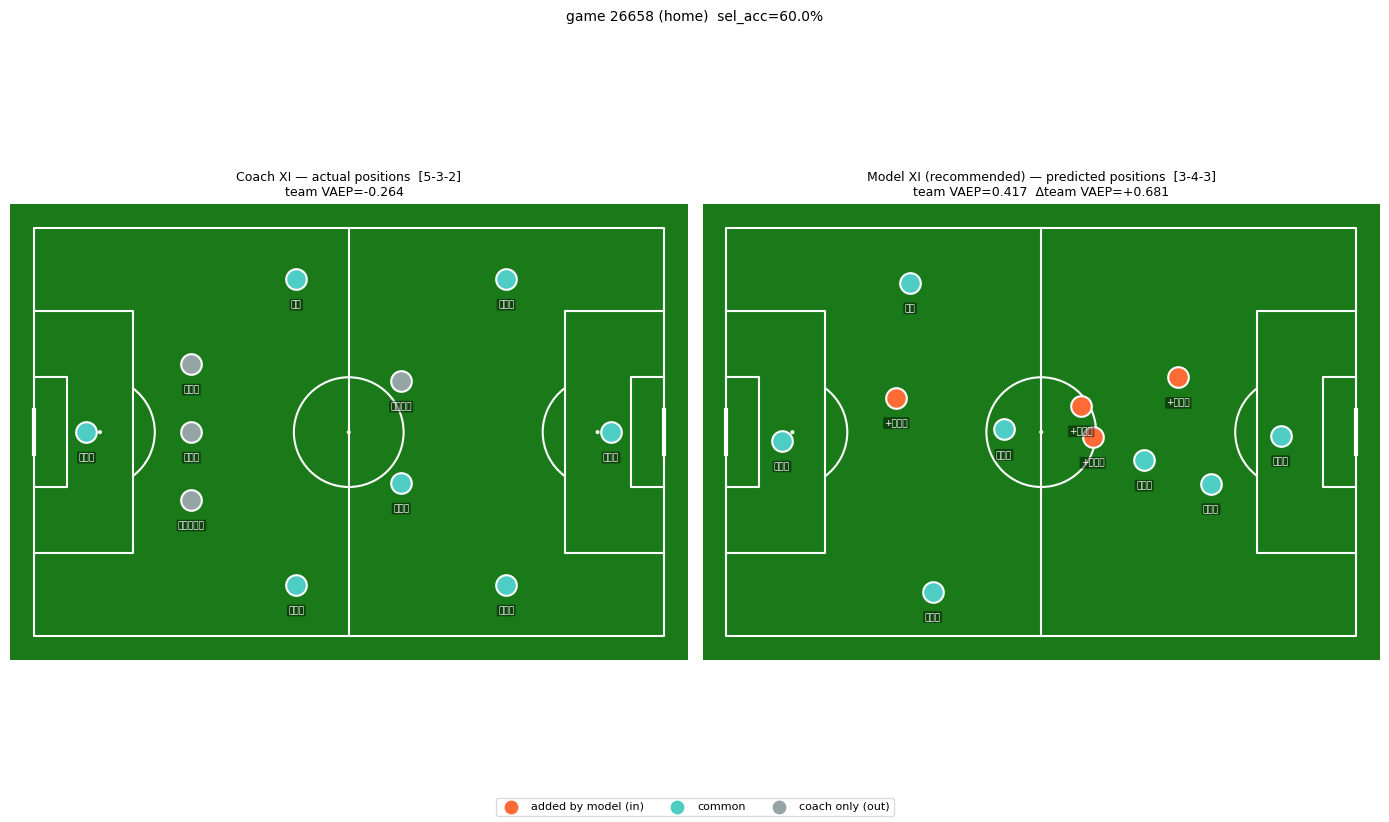

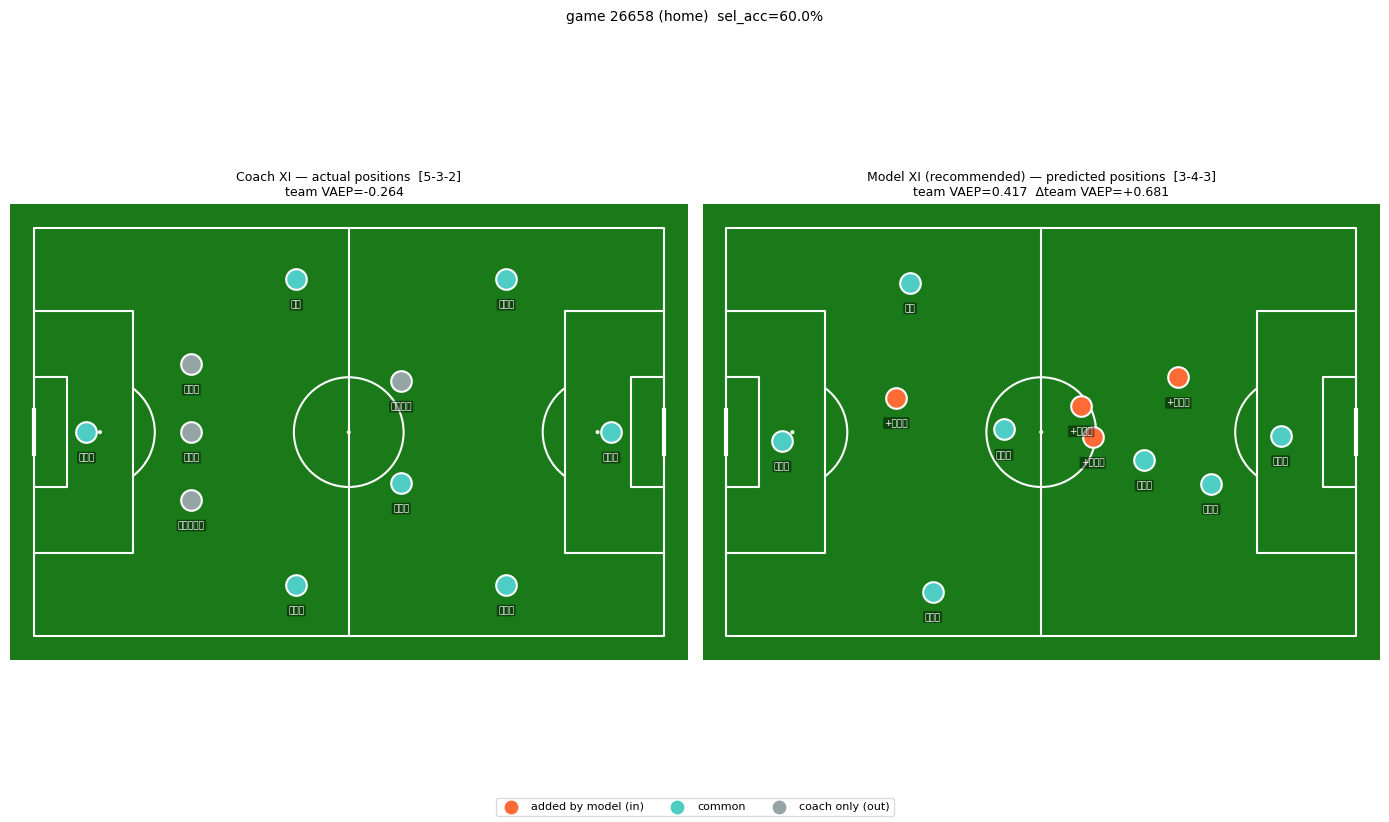

In [5]:
# ── Case-study reproduction ─────────────────────────────────────────────────
from experiments.min_minutes_eval import build_diff_ymap, fold_split   # fast mu/sd (same split as training)

ymap = build_diff_ymap()
_, mu, sd = fold_split(2021, SEED + 0, ymap)
gkids = _build_gkids()
model = H.load_model(CHECKPOINTS_DIR / f"{OURS}_stage2_fold0.pt", coord_skip=True, value_skip=True,
                     device=torch.device("cpu"))
rec = H.recommend(model, game_id=26658, side="home", mu=mu, sd=sd,
                  gkids=gkids, min_elig=900)
name, _ = H.player_meta()
print(f"coach v̂ = {rec['coach_vhat']:+.2f}   model v̂ = {rec['model_vhat']:+.2f}   Δ = {rec['delta_vhat']:+.2f}")
print("OUT :", [name.get(i, i) for i in rec['out_only']])
print("IN  :", [name.get(i, i) for i in rec['in_only']])
print("kept:", [name.get(i, i) for i in rec['model_ids'] if i not in rec['in_only']])
H.plot_pitch(rec, game_id=26658, side="home")


In [6]:
# ── (Optional) full reproduction from scratch ───────────────────────────────
# To re-run every training/eval run behind the tables and the case study
# (5-fold × 3 runs, several hours):
#   bash run_paper.sh
# See README 'Reproducing the paper' and the comments in run_paper.sh.
print("For full retraining, see run_paper.sh")


For full retraining, see run_paper.sh
